In [ ]:
import numpy as np
from qutip import *
from scipy.linalg import sqrtm, eigvalsh
from scipy.stats import linregress
from numba import njit, prange
import pickle
import os
import gc

## Fidelity
Generic definition : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \left( Tr \left[ \sqrt{ \sqrt{\rho} \sigma \sqrt{\rho} }\right] \right)^{2} $$ 
Definition for $ \rho $ Pure State and $ \sigma $ Mixed State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \langle \psi_{\rho} | \sigma | \psi_{\rho} \rangle $$
Definition for Pure State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = |\langle \psi_{\rho} | \psi_{\sigma} \rangle|^{2} $$
Definition for Qubits : 
$$ \mathcal{F}\left( \rho, \sigma \right) = Tr\left( \rho \, \sigma \right) + 2 \sqrt{Det\left ( \rho \right) \, Det\left ( \sigma \right)} $$
## Trace Distance
Generic definition : 
$$ \mathcal{T}\left( \rho, \sigma \right) = \frac{1}{2} Tr \left[ \sqrt{\left( \rho - \sigma \right)^{\dagger} \left( \rho - \sigma  \right)} \right] $$
### Relationship : Fuchs-van de Graaf inequality
$$ 1 - \sqrt{\mathcal{F}\left( \rho, \sigma \right)} \leq \mathcal{T}\left( \rho, \sigma \right) \leq \sqrt{1 - \mathcal{F}\left( \rho, \sigma \right)} $$

In [2]:
def fidelity_generic(rho, sigma):
    """
    Calculate the quantum fidelity between two generic density matrices.
    Formula: F(rho, sigma) = ( Tr[ sqrt( sqrt(rho) * sigma * sqrt(rho) ) ] )^2
    
    This version avoids scipy.linalg.sqrtm to prevent RuntimeWarnings, 
    using stable eigenvalue decomposition instead.
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The fidelity between rho and sigma (real number between 0 and 1).
    """
    # 1. Square root of rho using eigenvalue decomposition
    evals_rho, evecs_rho = np.linalg.eigh(rho)
    # Truncate any negative noise to 0.0 before taking the square root
    evals_rho = np.maximum(evals_rho, 0.0) 
    sqrt_rho = evecs_rho @ np.diag(np.sqrt(evals_rho)) @ evecs_rho.conj().T
    
    # 2. Inner matrix: sqrt(rho) * sigma * sqrt(rho)
    inner_matrix = sqrt_rho @ sigma @ sqrt_rho
    
    # Force exact Hermiticity to remove any small imaginary noise
    inner_matrix = 0.5 * (inner_matrix + inner_matrix.conj().T)
    
    # 3. Trace of the square root is the sum of the square roots of the eigenvalues
    evals_inner = eigvalsh(inner_matrix)
    # Again, truncate negative noise to 0.0 before square root
    evals_inner = np.maximum(evals_inner, 0.0)
    
    fidelity = np.sum(np.sqrt(evals_inner))**2
    
    # Ensure numerical errors do not push fidelity slightly above 1.0
    return min(1.0, fidelity)
    

In [ ]:
@njit
def fidelity_qubit(rho, sigma):
    """
    Calculate the exact quantum fidelity between two single-qubit (2x2) density matrices.
    Formula: F(rho, sigma) = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
    """
    # Trace of the matrix product
    tr_term = np.real(np.trace(rho @ sigma))
    
    # Determinants of the two density matrices
    det_rho = np.real(np.linalg.det(rho))
    det_sigma = np.real(np.linalg.det(sigma))
    
    # FIX NUMERICO: Tronchiamo a 0 gli eventuali valori negativi infinitesimi
    det_rho = max(0.0, det_rho)
    det_sigma = max(0.0, det_sigma)
    
    # Calculate fidelity using the analytical formula for qubits
    fidelity = tr_term + 2.0 * np.sqrt(det_rho * det_sigma)
    
    return fidelity

In [ ]:
@njit
def fidelity_qubit_single_term(p00, p11, c10, c01, sigma):
    """
    First build up the density matrix from the single terms, then
    Calculate the exact quantum fidelity between two single-qubit (2x2) density matrices.
    Formula: F(rho, sigma) = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
    """
    # Density Matrix build up
    rho = np.zeros((2, 2), dtype=complex)
    rho[0,0] = p00
    rho[0,1] = c01
    rho[1,0] = c10
    rho[1,1] = p11

    # Trace of the matrix product
    tr_term = np.real(np.trace(rho @ sigma))
    
    # Determinants of the two density matrices
    det_rho = np.real(np.linalg.det(rho))
    det_sigma = np.real(np.linalg.det(sigma))
    
    # FIX NUMERICO: Tronchiamo a 0 gli eventuali valori negativi infinitesimi
    det_rho = max(0.0, det_rho)
    det_sigma = max(0.0, det_sigma)
    
    # Calculate fidelity using the analytical formula for qubits
    fidelity = tr_term + 2.0 * np.sqrt(det_rho * det_sigma)
    
    return fidelity

In [4]:
def trace_distance_generic(rho, sigma):
    """
    Calculate the Trace Distance between two generic density matrices.
    Formula: T(rho, sigma) = 1/2 * Tr[ sqrt( (rho - sigma)^dagger * (rho - sigma) ) ]
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The trace distance between rho and sigma (real number between 0 and 1).
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Force exact Hermiticity to remove numerical noise
    diff = 0.5 * (diff + diff.conj().T)
    
    # Calculate the eigenvalues of the strictly Hermitian matrix 'diff'
    eigenvalues = eigvalsh(diff)
    
    # Trace distance is half the sum of the absolute eigenvalues
    t_dist = 0.5 * np.sum(np.abs(eigenvalues))
    
    # Ensure it stays within physical bounds
    return min(1.0, t_dist)
    

In [5]:
def trace_distance_qubit(rho, sigma):
    """
    Calculate the exact Trace Distance between two single-qubit (2x2) density matrices.
    For a 2x2 traceless Hermitian matrix (rho - sigma), Det(diff) = -lambda^2 <= 0.
    Therefore, the Trace Distance simplifies to sqrt(-Det(rho - sigma)).
    
    Parameters:
        rho (numpy.ndarray): First density matrix (2x2).
        sigma (numpy.ndarray): Second density matrix (2x2).
        
    Returns:
        float: The trace distance between rho and sigma.
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Determinant of the difference
    det_diff = np.real(np.linalg.det(diff))
    
    # Since det_diff should be <= 0, -det_diff should be >= 0.
    # We use max(0.0, ...) to truncate any negative noise before applying sqrt.
    val_under_sqrt = max(0.0, -det_diff)
    
    t_dist = np.sqrt(val_under_sqrt)
    
    return min(1.0, t_dist)
    

# Results Analysis

In [ ]:
# ====================================
# Physical & Simulation Parameters
# ====================================

# Site selector: 0 for |10>, 1 for |01>
site_index = 0

# Time parameters
dt = 0.01
tf = 100.0
time_steps = int(tf / dt)

# List of Number of trajectories to analyze
N_traj_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000]        

In [ ]:
# ============================================================
# GLOBAL CONFIGURATION :    
#   'normal'       → results_intermediate.pkl
#   'close_to_90'  → results_close_to_90_deg.pkl
# ============================================================

MODE = 'normal'   # <-- change: 'normal' or 'close_to_90'

# --- Paths ---
Output_dir   = '/home/francesco/Collisional_Methods/Results/Plot/Probability/Fidelity/Avg'

# --- Mapping automatico in base a MODE ---
_cfg = {
    'normal': {
        'Input_dir': "../Results/Data/Complete_rho/normal",
        'save_fidelity_time_avg': os.path.join(Output_dir, "Fidelity_time_avg.png"),
        'save_fidelity_max_value': os.path.join(Output_dir, "Fidelity_max_value.png"),
        'save_trace_distance_time_avg': os.path.join(Output_dir, "Trace_Distance_time_avg.png"),
        'save_trace_distance_max_value': os.path.join(Output_dir, "Trace_Distance_max_value.png"),
        'thetas_deg': [0, 30, 45, 60, 90],
    },
    'close_to_90': {
        'Input_dir': "../Results/Data/Complete_rho/close_to_90",
        'save_fidelity_time_avg': os.path.join(Output_dir, "Fidelity_time_avg_close_to_90_deg.png"),
        'save_fidelity_max_value': os.path.join(Output_dir, "Fidelity_max_value_close_to_90_deg.png"),
        'save_trace_distance_time_avg': os.path.join(Output_dir, "Trace_Distance_time_avg_close_to_90_deg.png"),
        'save_trace_distance_max_value': os.path.join(Output_dir, "Trace_Distance_max_value_close_to_90_deg.png"),
        'thetas_deg': [90, 89.9, 89.5, 89, 88.5, 88],
    },
}

cfg = _cfg[MODE]


In [ ]:
# ===========================
# General Setup for Plotting
# ===========================

# Global Style Settings (Matplotlib rcParams)
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# Automatic Figure Saving Function
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

### Data Extraction

In [ ]:
# =============================================
# Dictionaries to store only the averaged data 
# =============================================

# Structure: avg_fidelity_dict[theta][N_traj] = 1D_array_of_averaged_time_evolution
avg_fidelity_dict = {}

# avg_trace_dist_dict = {}  # Uncomment if you also want to average trace distance

print("Starting Lindblad data extraction")

# ====================
# Lindblad Extraction
# ====================

# Single extraction for Lindbad data, since they don't depend on theta !

# Format theta and dt for filename 
Lindblad_theta_rad = np.deg2rad(90)  # Always 90° for Lindblad

Lindblad_theta_str = f"{Lindblad_theta_rad:.6f}".replace(".", "p")
Lindblad_dt_str = f"{dt:.6f}".replace(".", "p")

 # File name
Lindblad_filename = f"result_theta{Lindblad_theta_str}_dt{Lindblad_dt_str}_Ntraj20000.npz"
Lindblad_filepath = os.path.join(cfg['Input_dir'], Lindblad_filename)

Lindblad_data = np.load(Lindblad_filepath)

rho_lindblad_complete = Lindblad_data['rho_list_lindblad']  # 4x4 dimension

rho_lindblad = np.zeros((time_steps, 2, 2), dtype=complex)
for t in range(time_steps):
    # Extract the 2x2 block corresponding to the single-excitation subspace  ATTENTION : inverted respect to Trajectories, already inverted here
    rho_lindblad[t,0,0] = rho_lindblad_complete[t, 1, 1]  # Index (1,1) -> |01><01|
    rho_lindblad[t,0,1] = rho_lindblad_complete[t, 2, 1]  # Index (2,1) -> |10><01|
    rho_lindblad[t,1,0] = rho_lindblad_complete[t, 1, 2]  # Index (1,2) -> |01><10|
    rho_lindblad[t,1,1] = rho_lindblad_complete[t, 2, 2]  # Index (2,2) -> |10><10|

# # Populations : Index (2,2) -> |10><10|, Index (1,1)  -> |01><01|    
# pop_lindblad_10 = np.real(rho_lindblad[:, 2, 2])
# pop_lindblad_01 = np.real(rho_lindblad[:, 1, 1])
    
# # Coherences: Index (2,1) -> |10><01|, Index (1, 2) -> |01><10|  ATTENTION : inverted respect to Trajectories, already inverted here
# cohe_lindblad_10_01 = rho_lindblad[:, 1, 2] 
# cohe_lindblad_01_10 = rho_lindblad[:, 2, 1]

print(" Lindblad data extraction completed")


In [ ]:
# ================================
# TRAJECTORY DATA EXTRACTION LOOP
# ================================
for theta in cfg['thetas_deg']:
    print(f"\nProcessing angle: {theta}°...")

    # Initialize the dictionary for the current angle
    if theta not in avg_fidelity_dict:
        avg_fidelity_dict[theta] = {}

    # -----------------
    # Input Data Setup
    # -----------------
    theta_rad = np.deg2rad(theta)
    theta_str = f"{theta_rad:.6f}".replace(".", "p")
    dt_str = f"{dt:.6f}".replace(".", "p")

    # Define filename and load data
    filename = f"result_theta{theta_str}_dt{dt_str}_Ntraj20000.npz"
    filepath = os.path.join(cfg['Input_dir'], filename)

    data = np.load(filepath)

    # Extract raw trajectory arrays
    pop_traj_10 = data['pop_00']
    pop_traj_01 = data['pop_11']
    cohe_traj_10_01 = data['coh_10_01'] 
    cohe_traj_01_10 = data['coh_01_10']

    print(f"Data extraction for {theta}° completed.")

    # ----------------
    # Avg calculation
    # ----------------
    print(f"Starting average & fidelity calculation for {theta}°...")

    for N in N_traj_list:
        # Initialize the array to store fidelity over time for N trajectories
        avg_fidelity_dict[theta][N] = np.zeros(time_steps)
        
        # Calculate averages over the specified number of trajectories
        pop_10_m   = np.mean(pop_traj_10[:, :N], axis=1)
        pop_01_m   = np.mean(pop_traj_01[:, :N], axis=1)
        coh_1001_m = np.mean(cohe_traj_10_01[:, :N], axis=1)
        coh_0110_m = np.mean(cohe_traj_01_10[:, :N], axis=1)

        # ---------------------
        # Fidelity calculation
        # ---------------------
        for t in range(time_steps):
            # Calculate fidelity with Lindblad at time t
            avg_fidelity_dict[theta][N][t] = fidelity_qubit_single_term(
                pop_10_m[t], pop_01_m[t], coh_1001_m[t], coh_0110_m[t], rho_lindblad[t]
            )

    # ==================
    # MEMORY MANAGEMENT
    # ==================
    # Close the file and delete heavy arrays to free up RAM
    data.close()
    del pop_traj_10, pop_traj_01, cohe_traj_10_01, cohe_traj_01_10, data
    
    # Force the garbage collector to clear the RAM immediately
    gc.collect() 
    
    print(f"Angle {theta}° fully processed and memory cleared.")

## Fidelity calculation

In [ ]:
# ====================================
# INFIDELITY CALCULATION (MAX & MEAN)
# ====================================

print("Starting Infidelity metrics calculation...")

# Dictionaries to store the calculated metrics for plotting
max_infidelity_results = {}
mean_infidelity_results = {}

for theta in cfg['thetas_deg']:
    max_vals = []
    mean_vals = []
    
    for N in N_traj_list:
        # Extract the averaged time-evolution fidelity array for this (theta, N)
        fid_time_array = avg_fidelity_dict[theta][N]
        
        # Calculate infidelity: 1 - Fidelity
        infidelity_array = 1.0 - fid_time_array
        
        # Calculate the maximum and temporal mean of the infidelity
        max_inf = np.max(infidelity_array)
        mean_inf = np.mean(infidelity_array)
        
        max_vals.append(max_inf)
        mean_vals.append(mean_inf)
        
    # Convert lists to NumPy arrays for plotting
    max_infidelity_results[theta] = np.array(max_vals)
    mean_infidelity_results[theta] = np.array(mean_vals)

print("Infidelity max and mean values computed successfully.")

## Plot

In [11]:
%matplotlib ipympl
from IPython.display import Image, display
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider
import matplotlib.ticker as ticker

### Fidelity in time

Theta   : ['0.000°', '30.000°', '45.000°', '60.000°', '90.000°']


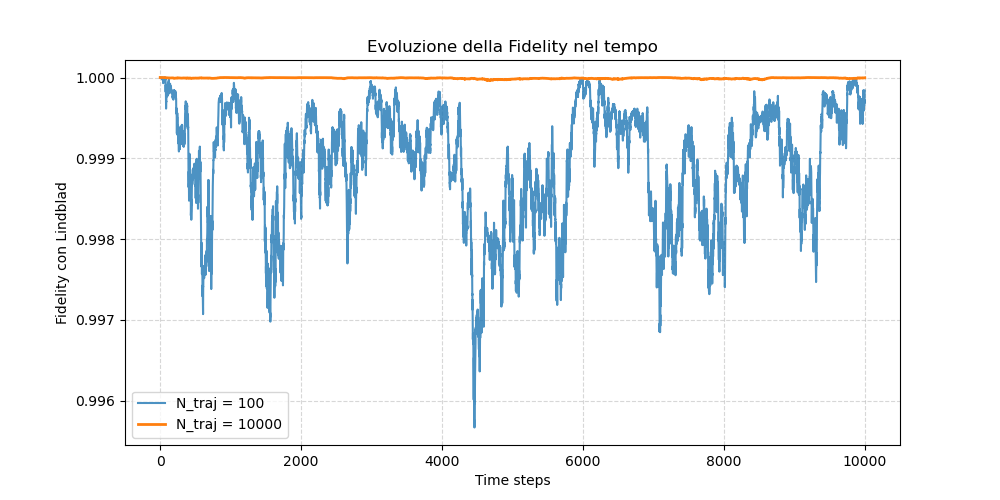

In [12]:
print(f"Theta   : {[f'{np.degrees(t):.3f}°' for t in results.keys()]}")
theta = np.radians(cfg['thetas_deg'][2])  # change angle
plt.close()
# In N_traj_list: l'indice 0 è 100 traiettorie, l'indice -1 è 10000 traiettorie
plt.figure(figsize=(10, 5))
plt.plot(Fidelity_tensors[theta][0, :], label='N_traj = 100', alpha=0.8)
plt.plot(Fidelity_tensors[theta][-1, :], label='N_traj = 10000', linewidth=2)

plt.xlabel("Time steps")
plt.ylabel("Fidelity con Lindblad")
plt.title("Evoluzione della Fidelity nel tempo")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Fidelity average over time for different Number of Trajectories

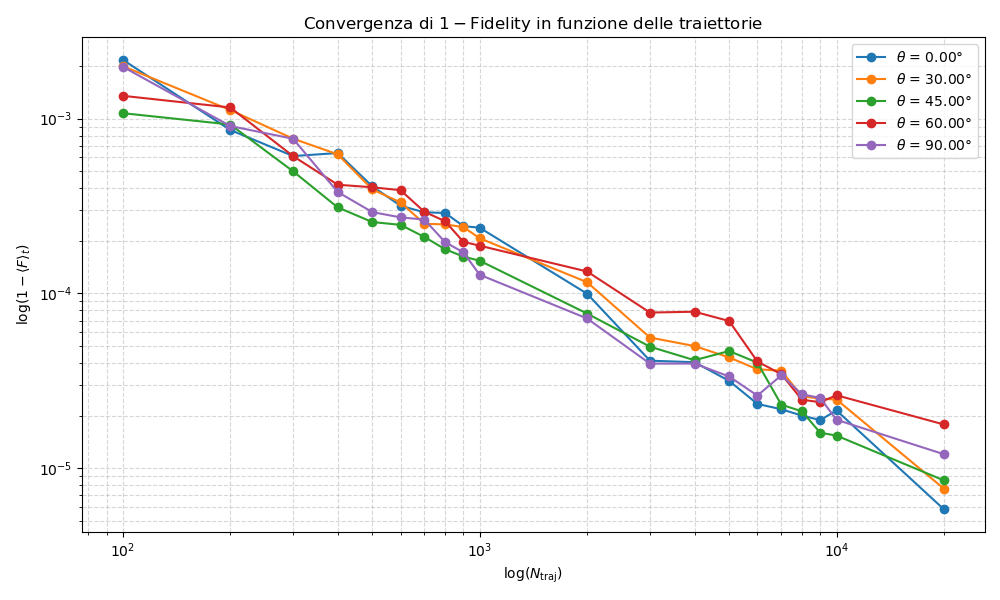

In [13]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili nei tuoi risultati
for theta, fid_matrix in Fidelity_tensors.items():
    
    # fid_matrix ha dimensione (N_traj, time_steps)
    # Calcoliamo la media lungo la dimensione del tempo (axis=1)
    fidelity_time_avg = np.mean(fid_matrix, axis=1)
    fidelity_time_avg = 1 - fidelity_time_avg
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva per questo specifico angolo
    plt.plot(N_traj_list, fidelity_time_avg, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

plt.xlabel(r"$\log(N_{\text{traj}})$")
plt.ylabel(r"$\log(1 - \langle F \rangle_t)$")
plt.title(r"Convergenza di $1 - \text{Fidelity}$ in funzione delle traiettorie")
# scala logaritmica per l'asse X 
plt.xscale('log')
plt.yscale('log')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

### Minimal Fidelity for different Number of Trajectories

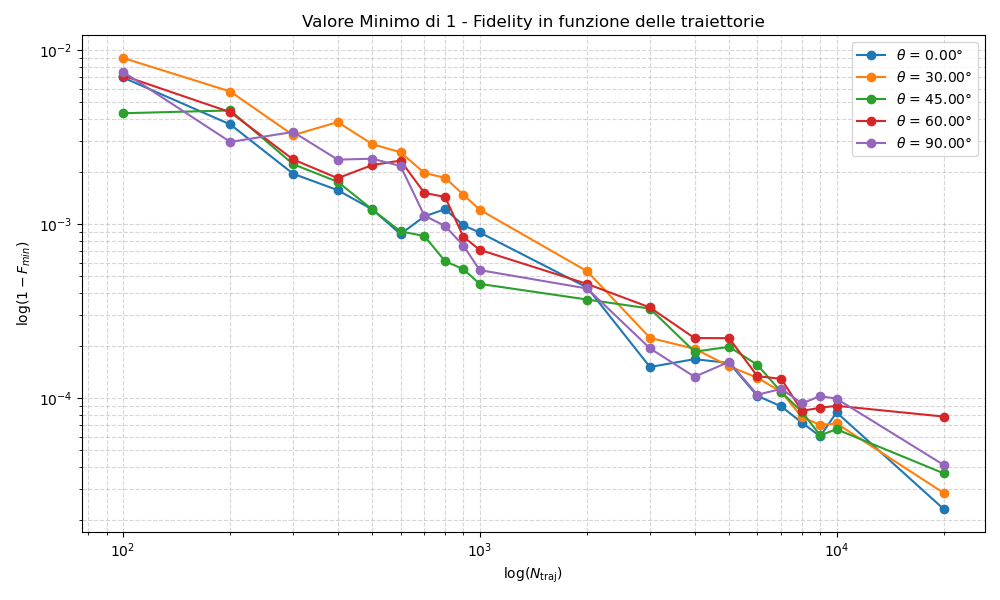

In [14]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili nei tuoi risultati
for theta, fid_matrix in Fidelity_tensors.items():
    
    # fid_matrix ha dimensione (N_traj, time_steps)
    # Calcoliamo il Minimo lungo la dimensione del tempo (axis=1)
    fidelity_min = np.min(fid_matrix, axis=1)
    fidelity_min = 1 - fidelity_min
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva per questo specifico angolo
    plt.plot(N_traj_list, fidelity_min, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

plt.xlabel(r"$\log(N_{\text{traj}})$")
plt.ylabel(r"$\log(1 - F_{min})$")
plt.title("Valore Minimo di 1 - Fidelity in funzione delle traiettorie")

# scala logaritmica per l'asse X 
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

## Trace Distance calculation

In [15]:
# Creiamo il dizionario per salvare i tensori di Trace Distance per ogni angolo
Trace_Distance_tensors = {}

# Ricaviamo le dimensioni dal primo tensore disponibile
primo_theta = list(rho_tensors.keys())[0]
num_traj = rho_tensors[primo_theta].shape[0]
time_steps = rho_tensors[primo_theta].shape[1]

print("Inizio il calcolo della Trace Distance...")

# Iteriamo su tutti gli angoli calcolati
for theta, rho_tensor in rho_tensors.items():
    
    # Inizializziamo una matrice 2D per le trace distance: (N_traj, time_steps)
    td_matrix = np.zeros((num_traj, time_steps), dtype=np.float64)
    
    for i in range(num_traj):
        for t in range(time_steps):
            
            # Estraiamo le matrici 2x2 per questo step
            rho_t = rho_tensor[i, t, :, :]
            sigma_t = rho_Lindblad[t, :, :]
            
            # Calcoliamo la Trace Distance usando la funzione analitica per Qubit
            td_matrix[i, t] = trace_distance_qubit(rho_t, sigma_t)
            
    # Salviamo la matrice nel dizionario
    Trace_Distance_tensors[theta] = td_matrix

print("Calcolo Trace Distance completato!")

Inizio il calcolo della Trace Distance...
Calcolo Trace Distance completato!


### Trace Distance in Time

Theta   : ['0.000°', '30.000°', '45.000°', '60.000°', '90.000°']


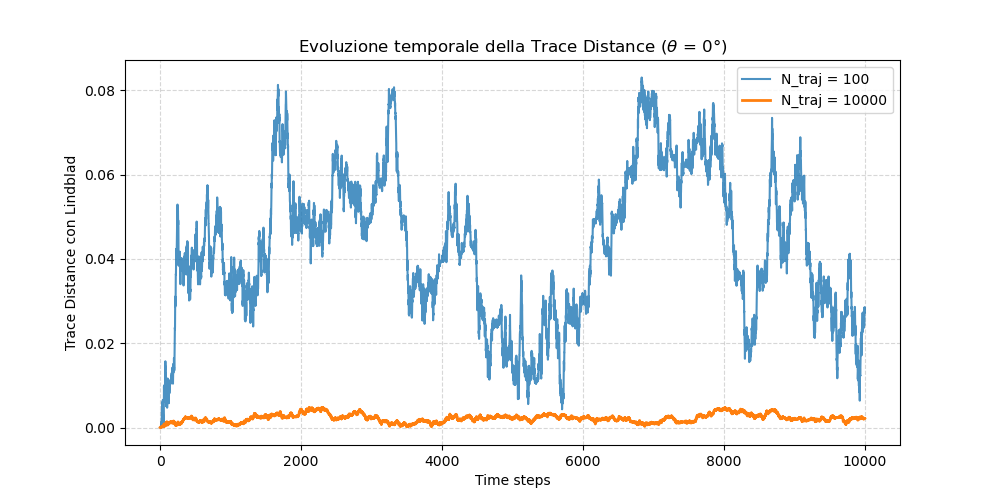

In [16]:
print(f"Theta   : {[f'{np.degrees(t):.3f}°' for t in results.keys()]}")
theta = np.radians(cfg['thetas_deg'][0])  # change angle

plt.figure(figsize=(10, 5))

# Trace Distance per N_traj basso (indice 0 della lista, es. 100 traiettorie)
plt.plot(Trace_Distance_tensors[theta][0, :], label='N_traj = 100', alpha=0.8)

# Trace Distance per N_traj alto (ultimo indice della lista, es. 10000 traiettorie)
plt.plot(Trace_Distance_tensors[theta][-1, :], label='N_traj = 10000', linewidth=2)

# Formattazione del grafico
plt.xlabel("Time steps")
plt.ylabel("Trace Distance con Lindblad")
plt.title(f"Evoluzione temporale della Trace Distance ($\\theta$ = {np.degrees(theta):.0f}°)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Trace Distance average over time for different Number of Trajectories

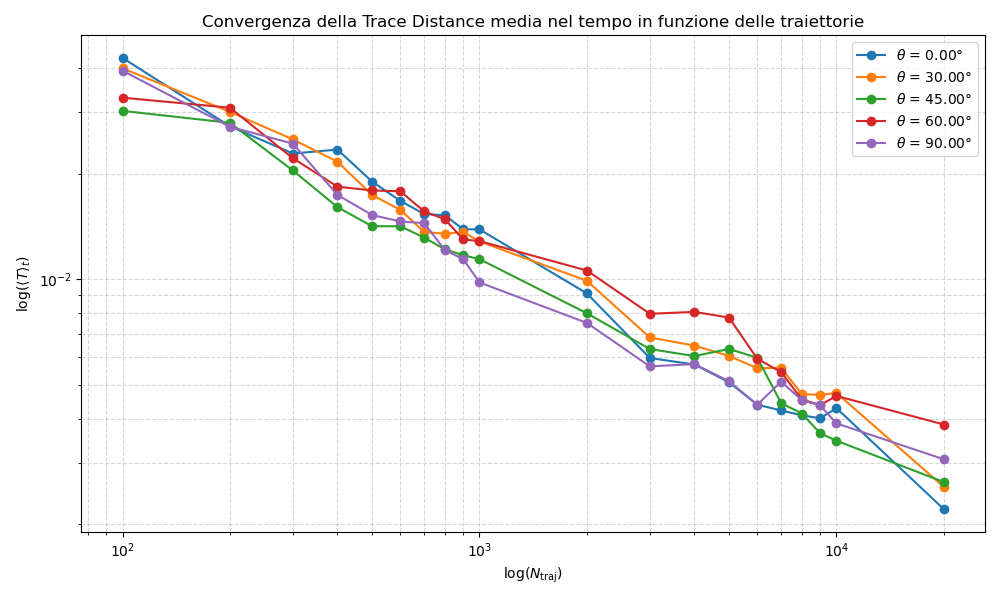

In [17]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili
for theta, td_matrix in Trace_Distance_tensors.items():
    
    # Calcoliamo la MEDIA lungo la dimensione del tempo (axis=1)
    td_time_avg = np.mean(td_matrix, axis=1)
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva
    plt.plot(N_traj_list, td_time_avg, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

# Formattazione
plt.xlabel(r"$\log(N_{\text{traj}})$")
plt.ylabel(r"$\log(\langle T \rangle_t)$")
plt.title("Convergenza della Trace Distance media nel tempo in funzione delle traiettorie")

# Scala logaritmica
plt.xscale('log')
plt.yscale('log')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

### Maximal Trace Distance for different Number of Trajectories

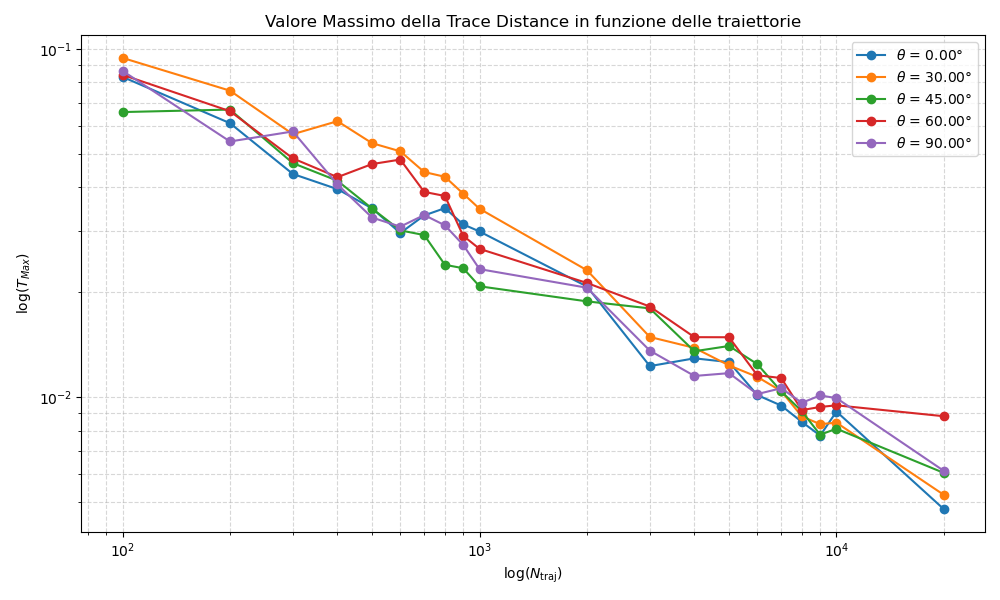

In [18]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili
for theta, td_matrix in Trace_Distance_tensors.items():
    
    # Calcoliamo il MASSIMO lungo la dimensione del tempo (axis=1)
    td_max = np.max(td_matrix, axis=1)
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva
    plt.plot(N_traj_list, td_max, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

# Formattazione
plt.xlabel(r"$\log(N_{\text{traj}})$")
plt.ylabel(r"$\log(T_{Max})$")
plt.title("Valore Massimo della Trace Distance in funzione delle traiettorie")

# Scala logaritmica
plt.xscale('log')
plt.yscale('log')


plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

### Fuchs-van de Graaf inequality

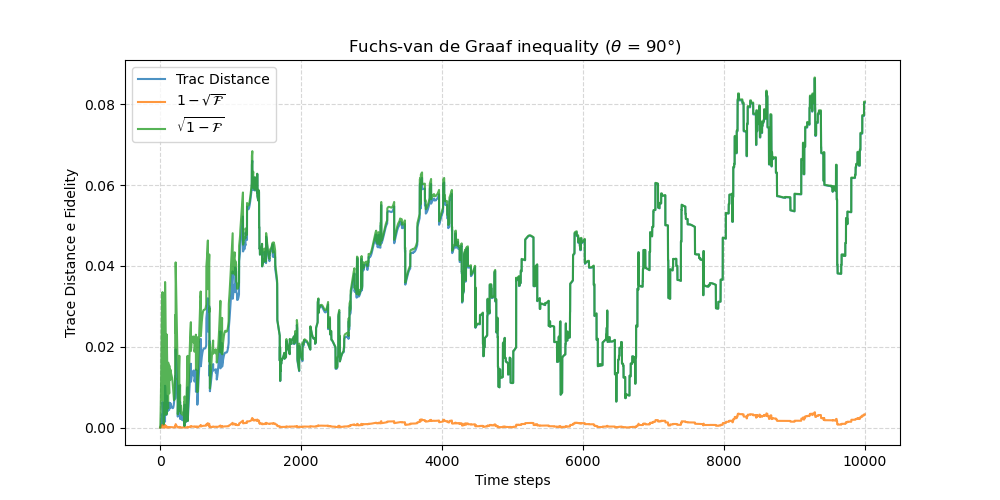

In [19]:
lower = 1 - np.sqrt(Fidelity_tensors[theta][0, :])
upper = np.sqrt(np.clip(1 - Fidelity_tensors[theta][0, :], 0.0, 1.0))

plt.figure(figsize=(10, 5))

# Trace Distance per N_traj basso (indice 0 della lista, es. 100 traiettorie)
plt.plot(Trace_Distance_tensors[theta][0, :], label='Trac Distance', alpha=0.8)
plt.plot(lower, label=r"$ 1 - \sqrt{\mathcal{F}} $", alpha=0.8)
plt.plot(upper, label=r"$ \sqrt{1 - \mathcal{F}} $", alpha=0.8)

# Formattazione del grafico
plt.xlabel("Time steps")
plt.ylabel("Trace Distance e Fidelity")
plt.title(f" Fuchs-van de Graaf inequality ($\\theta$ = {np.degrees(theta):.0f}°)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Mostriamo il plot
plt.show()

## Fidelity Fitting

In [20]:
# Preparo le liste per raccogliere TUTTI i dati per il fit globale
all_log_N = []
all_log_Infidelity = [] 

for theta, fid_matrix in Fidelity_tensors.items():
    # Calcolo la media nel tempo della fidelity per ogni N_traj
    fidelity_time_avg = np.mean(fid_matrix, axis=1)
    
    # L'errore Monte Carlo (Infedeltà) è 1 - F
    infidelity = 1.0 - fidelity_time_avg
    
    # Per fare il logaritmo, l'argomento deve essere strettamente > 0.
    # Se per 10000 traiettorie la fidelity è ESATTAMENTE 1.0, il log(0) darebbe errore.
    # Filtriamo via questi rari casi limite:
    valid_indices = infidelity > 0
    
    N_valid = np.array(N_traj_list)[valid_indices]
    inf_valid = infidelity[valid_indices]
    
    # Calcolo il logaritmo in base 10 e lo aggiungo al "calderone" globale
    all_log_N.extend(np.log10(N_valid))
    all_log_Infidelity.extend(np.log10(inf_valid))

# Converto le liste in array NumPy per poter fare le operazioni matematiche
all_log_N = np.array(all_log_N)
all_log_Infidelity = np.array(all_log_Infidelity)

# Fit Lineare: y = m * x + q
slope, intercept, r_value, p_value, std_err = linregress(all_log_N, all_log_Infidelity)

# Stampo i parametri della retta ricavati dal fit
print("=== Risultati del Fit Lineare Globale (scala log-log) ===")
print(f"Pendenza m della retta: {slope:.4f}")
print(f"Intercetta (q): {intercept:.4f}")
print(f"Coefficiente di correlazione (R^2): {r_value**2:.4f}")

=== Risultati del Fit Lineare Globale (scala log-log) ===
Pendenza m della retta: -0.9770
Intercetta (q): -0.8012
Coefficiente di correlazione (R^2): 0.9744


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_321188/221006515.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\log_{10}( N_{traj} )$")
/tmp/ipykernel_321188/221006515.py:19: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\log_{10}( 1 - \mathcal{F} )$")


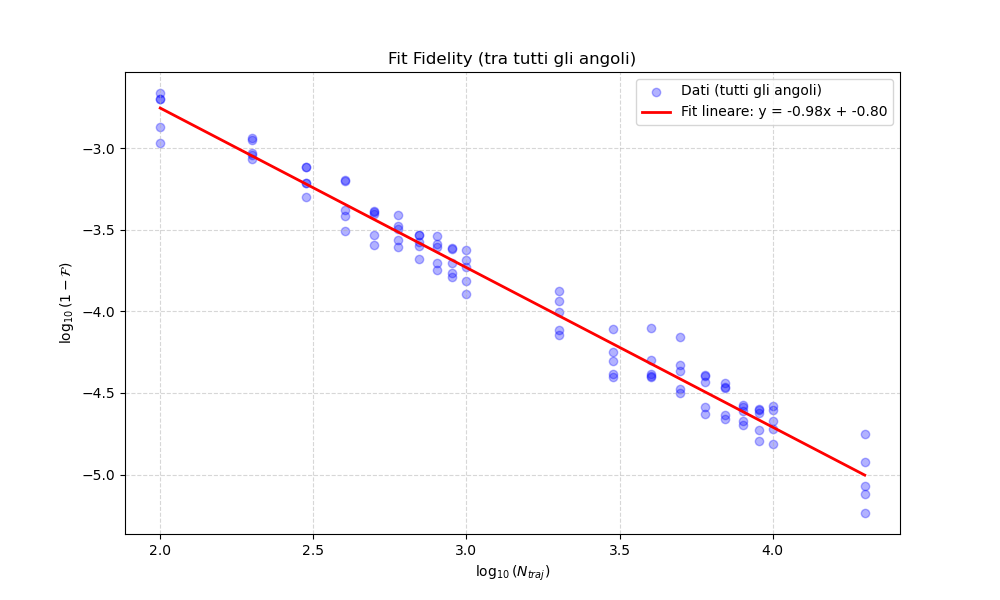

In [21]:
# ==========================================
# PLOT DEI DATI E DELLA RETTA DI FIT
# ==========================================
plt.figure(figsize=(10, 6))

# Scatter plot di tutti i dati grezzi (sovrapposti)
plt.scatter(all_log_N, all_log_Infidelity, color='blue', alpha=0.3, label='Dati (tutti gli angoli)')

# Costruisco la retta teorica del fit
x_fit = np.linspace(min(all_log_N), max(all_log_N), 100)
y_fit = slope * x_fit + intercept

# Plotto la retta
plt.plot(x_fit, y_fit, color='red', linewidth=2, 
         label=f'Fit lineare: y = {slope:.2f}x + {intercept:.2f}')

# Formattazione
plt.xlabel("$\log_{10}( N_{traj} )$")
plt.ylabel("$\log_{10}( 1 - \mathcal{F} )$")
plt.title("Fit Fidelity (tra tutti gli angoli)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Trace Distance Fitting

In [22]:
# Preparo le liste per raccogliere TUTTI i dati per il fit globale
all_log_N_td = []
all_log_TD = [] 

for theta, td_matrix in Trace_Distance_tensors.items():
    # Calcolo la media nel tempo della Trace Distance per ogni N_traj
    td_time_avg = np.mean(td_matrix, axis=1)
    
    # Per il logaritmo, escludiamo eventuali zeri esatti (anche se rari nei Monte Carlo)
    valid_indices = td_time_avg > 0
    
    N_valid = np.array(N_traj_list)[valid_indices]
    td_valid = td_time_avg[valid_indices]
    
    # Calcolo il logaritmo in base 10 e lo aggiungo al "calderone" globale
    all_log_N_td.extend(np.log10(N_valid))
    all_log_TD.extend(np.log10(td_valid))

# Converto le liste in array NumPy per le operazioni matematiche
all_log_N_td = np.array(all_log_N_td)
all_log_TD = np.array(all_log_TD)

# Eseguo il Fit Lineare: y = m * x + q
slope_td, intercept_td, r_value_td, p_value_td, std_err_td = linregress(all_log_N_td, all_log_TD)

# Stampo i parametri della retta ricavati dal fit
print("=== Risultati del Fit Lineare Globale (Trace Distance) ===")
print(f"Pendenza (m) della retta: {slope_td:.4f}")
print(f"Intercetta (q): {intercept_td:.4f}")
print(f"Coefficiente di correlazione (R^2): {r_value_td**2:.4f}")


=== Risultati del Fit Lineare Globale (Trace Distance) ===
Pendenza (m) della retta: -0.4857
Intercetta (q): -0.4530
Coefficiente di correlazione (R^2): 0.9720


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_321188/4275402745.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\log_{10}( N_{traj} )$")
/tmp/ipykernel_321188/4275402745.py:19: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\log_{10}( \mathcal{T} )$")


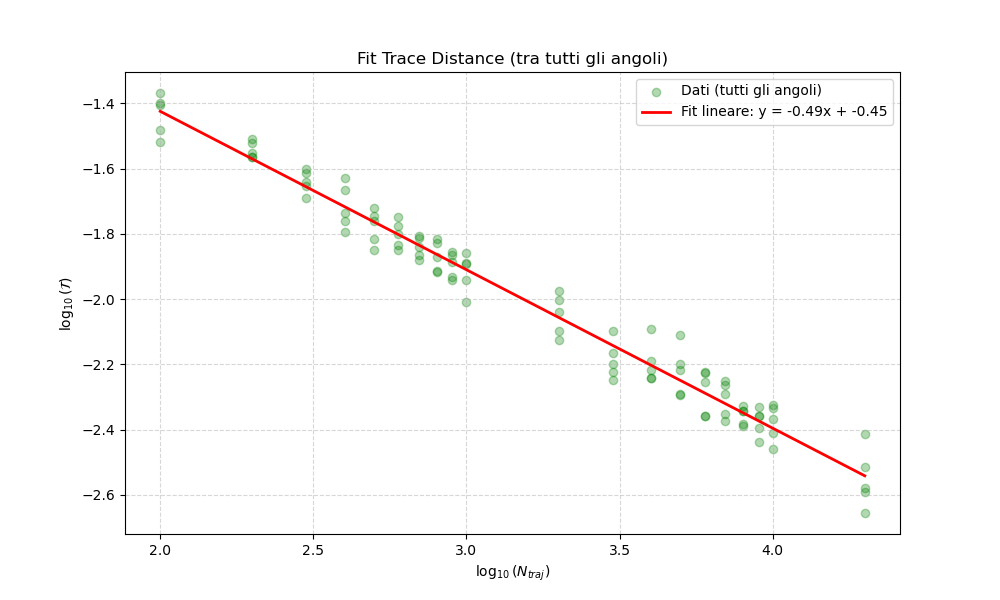

In [23]:
# ==========================================
# PLOT DEI DATI E DELLA RETTA DI FIT
# ==========================================
plt.figure(figsize=(10, 6))

# Scatter plot di tutti i dati grezzi (sovrapposti)
plt.scatter(all_log_N_td, all_log_TD, color='green', alpha=0.3, label='Dati (tutti gli angoli)')

# Costruisco la retta teorica del fit
x_fit_td = np.linspace(min(all_log_N_td), max(all_log_N_td), 100)
y_fit_td = slope_td * x_fit_td + intercept_td

# Plotto la retta
plt.plot(x_fit_td, y_fit_td, color='red', linewidth=2, 
         label=f'Fit lineare: y = {slope_td:.2f}x + {intercept_td:.2f}')

# Formattazione
plt.xlabel("$\log_{10}( N_{traj} )$")
plt.ylabel("$\log_{10}( \mathcal{T} )$")
plt.title("Fit Trace Distance (tra tutti gli angoli)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()